This notebook is used to simplify the code of the Zhu model and verify the plots with the Andrews model .

In [1]:
# import everything first

# import everything first:
import numpy as np
import astropy.constants as const
import astropy.units as u
from matplotlib import pyplot as plt
import sys
import pickle
from joblib import load
from joblib import Parallel, delayed
import os
import pandas as pd

In [2]:
# import all the constants in cgs unit
# Constants
G = 6.674e-8        # cm^3 g^-1 s^-2
sigmaB = 5.67e-5    # erg cm^-2 s^-1 K^-4
kB = 1.381e-16      # erg/K
L_sun = 3.828e33    # erg/s
R_p = 7.149e9       # Jupiter radius in cm
AU = 1.496e13       # cm
L_jup = 3.846e30  # erg/s

# Physical constants
M_sun = 1.989e33 
M_jup = 1.898e30
R_jup = 7.149e9
sec_per_yr = 3.156e7
Rgas = 8.314e7  # erg/(mol K)


Import the luminosity and planet radius relationship from the Andrews Model.

In [3]:
Lp_from_Mp = load('d:/CPD_MPIA/utils/Lp_from_Mp.pkl')
Rp_from_Mp = load('d:/CPD_MPIA/utils/Rp_from_Mp.pkl')

Define the Planck's function as a function of wavelength.

In [4]:
def B_lambda(lam, T):
    """
    Planck function in wavelength (erg s^-1 cm^-2 Hz^-1 sr^-1)
    lam: wavelength in cm
    T: temperature in K
    """
    h = 6.626e-27  # erg*s
    c = 2.998e10   # cm/s
    k = 1.381e-16  # erg/K
    return (2*h*c**2 / lam**5) / (np.exp(h*c/(lam*k*T)) - 1)

Define the Zhu model here.


For the test of the DSHARP gaps,  default parameters used will be

|Mdot|alpha|lambda|
|-|-|-|
| 1.56e-6 M_jup/yr |1e-3 |1.3 mm|


Additional Parameters fixed here but not found in the Andrews model: 


| mu| kappaR| T_ISM|
|-|-|-|
|2.3| 10 cm^2/g|10 K|



HD1423006 specific parameter from DSHARP era:

|M_star | d_pc | Lum_star | 
|-|-|-|
|1.56 M_sun| 167 pc| 3.8 L_sun|


In [5]:
def calculate_disk_properties_zhu(M_star = 1.56, Mp = 1, Mdot = 1.56e-6, alpha = 1e-3, kappaR = 10 , rp = 165, d_pc = 167, 
                             lam_mm=1.3, 
                            T_ISM=10.0, Lstar = 3.8,  mu=2.3, spec_flux  = None , show_results = False, Rout=None):
    """
    Calculate disk temperature profiles and millimeter flux.
    
    Parameters:
    -----------
    M_star : float
        Stellar mass (M_sun)

    Mp : float
        Planet mass (M_jup)
    Mdot : float  
        Accretion rate (M_jup/yr)
    alpha : float
        Viscosity parameter
    kappaR : float
        Rosseland opacity (cm^2/g)
    Rp : float
        Planet radius (Rjup)
    rp : float
        distance of planet from star (au)  
    d_pc : float
        Distance (pc)
    lam_mm : float
        Wavelength (mm)
    T_ISM : float
        Interstellar medium temperature (K)
    Lplanet : float
        Planet luminosity (L_sun)
    mu : float
        Mean molecular weight

    Lstar : float
        Stellar luminosity (L_sun)
        
    Returns:
    --------
    dict : Dictionary containing R, temperatures, Sigma, tau_mm, Tb, F_nu_tot
    """
    # ================================================================
    # === 1. Convert Input Parameters to CGS Units ===================
    # ================================================================
    M_star = M_star * M_sun                 # [g]
    Mp = Mp * M_jup                         # [g]
    Mdot = Mdot * M_jup / sec_per_yr        # [g/s]
    rp = rp * AU                            # [cm]
    Rp = Rp_from_Mp(Mp / M_jup) * R_jup     # [cm]

    # Luminosities
    Lplanet = Lp_from_Mp(Mp / M_jup) * L_sun  # [erg/s]
    Lstar = Lstar * L_sun                     # [erg/s]

    # ================================================================
    # === 2. Define Radial Grid ======================================
    # ================================================================
    if Rout is None:
        Rout = (1/3) * rp * (Mp / (3 * M_star))**(1/3)   # [cm]
    else:
        Rout = Rout * AU                                 # assume input Rout in AU

    R = np.geomspace(Rp * 1.01, Rout, 100)               # [cm] , times 1.01 to avoid R=Rp

    # ================================================================
    # === 3. External Irradiation Temperatures =======================
    # ================================================================
    # Accretion luminosity (planetary boundary layer)
    L_irr = G * Mp * Mdot / (2.0 * Rp)                   # [erg/s]
    T_irr = (L_irr / (40 * np.pi * sigmaB * R**2))**0.25 # [K]

    # Planetary irradiation
    T_irr_p = (0.1 * Lplanet / (4 * np.pi * sigmaB * R**2))**0.25  # [K]

    # Stellar irradiation
    phi_flare = 0.02
    T_irr_star = (phi_flare * Lstar / (8 * np.pi * sigmaB * rp**2))**0.25  # [K]

    # Combine all sources + ISM background
    T_ext = (T_irr**4 + T_irr_p**4 + T_irr_star**4 + T_ISM**4)**0.25       # [K]

    # ================================================================
    # === 4. Effective Temperature Profile ===========================
    # ================================================================
    Teff = ((3.0 * G * Mp * Mdot) / (8.0 * np.pi * sigmaB * R**3) *
            (1.0 - np.sqrt(Rp / R)))**0.25                                   # [K]

    # ================================================================
    # === 5. Surface Density Σ(R) ====================================
    # ================================================================
    Rgas = 8.314e7  # [erg/(mol*K)]

    # (a) Optically thick regime (Zhu eq. 6)
    term = (sigmaB * G * Mp * Mdot**3 / (alpha**4 * np.pi**3 * kappaR))**0.2
    mu_term = (mu / Rgas)**0.8
    factor = (1 - np.sqrt(Rp / R))**(3/5)
    Sigma6 = ((2**(7/5)) / (3**(6/5))) * term * mu_term * factor * R**(-3/5)  # [g/cm^2]

    # (b) Optically thin regime (Zhu eq. 7)
    Omega = np.sqrt(G * Mp / R**3)
    Sigma7 = (Mdot * mu * Omega) / (3.0 * np.pi * alpha * Rgas * T_ext)       # [g/cm^2]

    # (c) Take minimum of the two
    Sigma = np.minimum(Sigma6, Sigma7)

    # ================================================================
    # === 6. Midplane Temperature ====================================
    # ================================================================
    A = (9 * G * Mp * Mdot * Sigma * kappaR) / (128 * np.pi * sigmaB * R**3)
    f = (1.0 - np.sqrt(Rp / R))
    T_c = (A * f + T_ext**4)**0.25                                            # [K]

    # ================================================================
    # === 7. Brightness Temperature and Optical Depth ================
    # ================================================================
    kappa_mm = 0.034 * (0.87 / lam_mm)                                        # [cm^2/g]
    tau_mm = 0.5 * kappa_mm * Sigma                                           # dimensionless

    # Two regimes:
    Tb_thin = 2.0 * tau_mm * T_c
    Tb_thick = ((3.0/8.0) * (kappaR / kappa_mm) * Teff**4 + T_ext**4)**0.25

    Tb = np.where(tau_mm <= 0.5, Tb_thin, Tb_thick)                           # [K]

    # ================================================================
    # === 8. Area-Averaged Brightness Temperature ====================
    # ================================================================
    dR = np.diff(R)
    Rmid = 0.5 * (R[:-1] + R[1:])
    Tbmid = 0.5 * (Tb[:-1] + Tb[1:])
    Tb_avg = np.sum(Tbmid * 2 * np.pi * Rmid * dR) / (np.pi * (Rout**2 - Rp**2))

    val = (3/8) * (kappaR / kappa_mm) * Teff**4 + T_ext**4
    Sigma_tau05 = (val - T_ext**4)*(1-(Rp/R)**(0.5))**(-1)*(128*np.pi*R**3*sigmaB)/(9*G*Mp*Mdot*kappaR)

    M_cpd = np.trapz(2 * np.pi * R * Sigma_tau05, R) / 1.898e30  # Jupiter masses

    # ================================================================
    # === 9. Flux Density (Rayleigh-Jeans Approximation) =============
    # ================================================================
    I_RJ = 2.0 * kB * Tb / (lam_mm * 0.1)**2                                 # [erg cm^-2 s^-1 Hz^-1 sr^-1]
    F_nu_mid = 0.5 * (I_RJ[:-1] + I_RJ[1:])
    F_nu_tot = np.sum(F_nu_mid * 2 * np.pi * Rmid * dR)                      # [erg s^-1 Hz^-1]

    d_cm = d_pc * 3.086e18                                                   # [cm]
    F_nu_obs = F_nu_tot / d_cm**2                                            # [erg s^-1 cm^-2 Hz^-1]
    F_microJy = F_nu_obs / 1e-29                                             # [µJy]

    # ================================================================
    # === 10. Equaate CPD mass to power law sigma to sigma ===========
    # ================================================================
    M_dust = np.trapz(2 * np.pi * R * Sigma, R) / 1.898e30                  # [Earth masses]

    # ================================================================
    # === 11. Optional Diagnostics ===================================
    # ================================================================
    if spec_flux is not None:
        M_dust_source = spec_flux * 1e-29 * d_cm**2 / (kappa_mm * B_lambda(lam_mm * 0.1, Tb_avg))
        print(f"M_dust_source = {M_dust_source / 5.972e27:.3e} M_earth")

    if show_results:
        print(f"Rout = {Rout / AU:.2f} au")
        print(f"Tb_avg = {Tb_avg:.1f} K")
        print(f"F_nu_tot = {F_microJy:.2f} µJy")

    # ================================================================
    # === 12. Return Results =========================================
    # ================================================================
    return {
        "R": R,
        "Rout": Rout / AU,
        "R_AU": R / AU,
        "T_ext": T_ext,
        "Teff": Teff,
        "T_c": T_c,
        "Tb": Tb,
        "Sigma": Sigma,
        "tau_mm": tau_mm,
        "F_nu_tot": F_microJy,
        "Tb_avg": Tb_avg,
        "M_dust": M_dust,
        "T_irr": T_irr,
        "T_irr_p": T_irr_p,
        "T_irr_star": T_irr_star,
        "M_cpd": M_cpd
    }



Define the compute flux function.


What needs to be careful here:
- Not mixing up KappaR and KappaMM
- Not mixing up rp (AU) and Rp(Rjup)
- The nested loop picking up correct indices.

In [6]:
def zhu_plots_flux_map(target_flux_arr, disk_arr=None, rp=165, lam_mm=1.25, alpha=1e-3, plotmass=True , color = '5sigsource', y_max = 0.8, y_min= 0.05):
    """
    Make a DSHARP-style 2D flux map: 
    - x-axis: log10(Mp/Mjup)
    - y-axis: Rcpd / RHill -> normalised disk outer radius
    - shading: log10(Fnu [µJy]) or log10(M_dust [M_earth])
    - contours: recovery flux thresholds

    Parameters
    ----------
    target_flux_arr : list
        Flux thresholds (µJy) for contour level.
    disk_arr : list
        [disk_name, M_star (Msun), distance (pc), Lstar (Lsun)]
    rp : float
        Planet orbital radius (AU).
    lam_mm : float
        Observing wavelength in mm.
    alpha : float
        Viscosity parameter.
    """
    if disk_arr is None:
        disk_arr = ["Unknown", 1.0, 100, 1.0]

    # Grids
    Mp_grid = np.logspace(-2, 1, 80)       # 0.01 - 10 Mjup
    Rout_frac_grid = np.linspace(y_min, y_max, 60)  # fraction of RH   -> w
    M_star_jup = disk_arr[1] * 1047.56     # convert Msun to Mjup for explicit RHill calc

    # Array of flux with 2D shape ( Rout_frac, Mp)
    Flux_vals = np.zeros((len(Rout_frac_grid), len(Mp_grid)))
    M_dust = np.zeros((len(Rout_frac_grid), len(Mp_grid)))

    # Compute flux grid , for value combination in Rout and MP
    for i, frac in enumerate(Rout_frac_grid):
        for j, Mp in enumerate(Mp_grid):
            RHill = rp * (Mp / (3 * M_star_jup))**(1/3)
            print(f'Calculating for Mp = {Mp:.3f} Mjup, Rout_frac = {frac:.3f} -> RHill = {RHill:.2f} au')
            Rout = frac * RHill
            out = calculate_disk_properties_zhu(
                    M_star=disk_arr[1],
                    Mp=Mp,
                    Mdot=Mp*1e-6,   # stellar mass (M jup)/ Myr
                    alpha=alpha,
                    rp=rp,
                    d_pc=disk_arr[2],
                    lam_mm=lam_mm,
                    T_ISM=10.0,
                    Lstar=disk_arr[3],
                    Rout=Rout,
                )
            Flux_vals[i, j] = out['F_nu_tot']
            # Mcpd in Jupiter mass
            M_dust[i,j] = out['M_cpd']  # convert Earth mass to Jupiter mass
            print(f' The maximum tau for Rout  = {i} and is {np.max(out["tau_mm"]):.3e} ')

    # Mask out flux values below the minimum target flux (or 1 sigma level )
    min_flux = min(target_flux_arr) # µJy
    masked_Flux_vals = np.where(Flux_vals >= min_flux, Flux_vals, np.nan)
    masked_M_dust = np.where(Flux_vals >= min_flux, M_dust, np.nan)

    sigma_ujy = target_flux_arr[0]  # Base noise level in µJy
    sigma_levels = [1, 2, 3, 5]  # Sigma multiples to show
    flux_levels = [n * sigma_ujy for n in sigma_levels]  # Actual flux thresholds
    
    # Plot
    fig, ax = plt.subplots(figsize=(7, 5))

    # color scheme

    if color == '5sigsource':
        cmap = 'Blues'
    elif color == 'planet':
        cmap = 'Greens'
    elif color == 'external':
        cmap = 'Purples'


    if plotmass:
        vmin = np.nanmin(np.log10(masked_M_dust))
        vmax = np.nanmax(np.log10(masked_M_dust))
        cf = ax.contourf(
            np.log10(Mp_grid), Rout_frac_grid, np.log10(masked_M_dust),
            levels=np.linspace(vmin, vmax, 7), cmap=cmap, extend='both'
        )  
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$\log_{10}(M_{\rm dust}/M_{\rm Jup})$', fontsize=11)
    else:
        # Use linear flux levels for filled contours
        cf = ax.contourf(
            np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
            levels=flux_levels, cmap=cmap, extend='both'
        )
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$F_\nu\, [\mu{\rm Jy}]$', fontsize=11)

    cs = ax.contour(
        np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
        levels=flux_levels,
        colors='black', linewidths=1.5, linestyles='dashed', alpha=0.8
    )
    # Label contours with sigma notation
    labels = [f'{n}σ' for n in sigma_levels]
    fmt = {level: label for level, label in zip(flux_levels, labels)}
    ax.clabel(cs, fmt=fmt, fontsize=10, inline=True)
        

    # Overlay ALMA angular resolution limit
    # theta_beam = disk_arr[4]  # arcsec
    d_pc = disk_arr[2]
    # For each Mp, calculate the  Rout_frac = theta_beam * d_pc / RHill
    RHill_arr = rp * (Mp_grid / (3 * M_star_jup))**(1/3)
    Rout_frac_beam =  7.4/ (2*RHill_arr)  # this seems to give overestimation ,(theta_beam * d_pc)
    # for each planet mass, or for each Rout give a Mp 
    ax.plot(np.log10(Mp_grid), Rout_frac_beam, color='red', linestyle='-', linewidth=2, label='ALMA detection limit')
    print(f'Min Rout_frac for ALMA detection limit: {np.min(Rout_frac_beam):.3f}')


    # Axis labels
    ax.set_xlabel(r"$\log_{10}(M_p/M_{Jup})$")
    ax.set_ylabel(r"$R_{\rm cpd}/R_H$")
    ax.set_ylim(y_min, y_max)

    # Colorbar

    ax.set_title(f"{disk_arr[0]} at $r_p$={rp:.1f} AU, α={alpha}, κ=2.4 cm²/g")

    plt.tight_layout()
    plt.show()

Calculating for Mp = 0.010 Mjup, Rout_frac = 0.050 -> RHill = 0.28 au
 The maximum tau for Rout  = 0 and is nan 
Calculating for Mp = 0.011 Mjup, Rout_frac = 0.050 -> RHill = 0.29 au
 The maximum tau for Rout  = 0 and is 2.288e+01 
Calculating for Mp = 0.012 Mjup, Rout_frac = 0.050 -> RHill = 0.30 au
 The maximum tau for Rout  = 0 and is 2.421e+01 
Calculating for Mp = 0.013 Mjup, Rout_frac = 0.050 -> RHill = 0.30 au
 The maximum tau for Rout  = 0 and is 2.559e+01 
Calculating for Mp = 0.014 Mjup, Rout_frac = 0.050 -> RHill = 0.31 au
 The maximum tau for Rout  = 0 and is 2.702e+01 
Calculating for Mp = 0.015 Mjup, Rout_frac = 0.050 -> RHill = 0.32 au
 The maximum tau for Rout  = 0 and is 2.851e+01 
Calculating for Mp = 0.017 Mjup, Rout_frac = 0.050 -> RHill = 0.33 au
 The maximum tau for Rout  = 0 and is 3.004e+01 
Calculating for Mp = 0.018 Mjup, Rout_frac = 0.050 -> RHill = 0.34 au
 The maximum tau for Rout  = 0 and is 3.163e+01 
Calculating for Mp = 0.020 Mjup, Rout_frac = 0.050 -> 

C:\Users\LHEM\AppData\Local\Temp\ipykernel_6300\340935018.py:73: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet / (4 * np.pi * sigmaB * R**2))**0.25  # [K]
C:\Users\LHEM\AppData\Local\Temp\ipykernel_6300\340935018.py:136: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_cpd = np.trapz(2 * np.pi * R * Sigma_tau05, R) / 1.898e30  # Jupiter masses
C:\Users\LHEM\AppData\Local\Temp\ipykernel_6300\340935018.py:152: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  M_dust = np.trapz(2 * np.pi * R * Sigma, R) / 1.898e30                  # [Earth masses]


 The maximum tau for Rout  = 12 and is 5.887e+02 
Calculating for Mp = 1.338 Mjup, Rout_frac = 0.203 -> RHill = 1.43 au
 The maximum tau for Rout  = 12 and is 6.217e+02 
Calculating for Mp = 1.461 Mjup, Rout_frac = 0.203 -> RHill = 1.47 au
 The maximum tau for Rout  = 12 and is 6.576e+02 
Calculating for Mp = 1.594 Mjup, Rout_frac = 0.203 -> RHill = 1.51 au
 The maximum tau for Rout  = 12 and is 6.968e+02 
Calculating for Mp = 1.740 Mjup, Rout_frac = 0.203 -> RHill = 1.56 au
 The maximum tau for Rout  = 12 and is 7.395e+02 
Calculating for Mp = 1.899 Mjup, Rout_frac = 0.203 -> RHill = 1.60 au
 The maximum tau for Rout  = 12 and is 7.859e+02 
Calculating for Mp = 2.072 Mjup, Rout_frac = 0.203 -> RHill = 1.65 au
 The maximum tau for Rout  = 12 and is 8.361e+02 
Calculating for Mp = 2.262 Mjup, Rout_frac = 0.203 -> RHill = 1.70 au
 The maximum tau for Rout  = 12 and is 8.899e+02 
Calculating for Mp = 2.468 Mjup, Rout_frac = 0.203 -> RHill = 1.75 au
 The maximum tau for Rout  = 12 and is 9

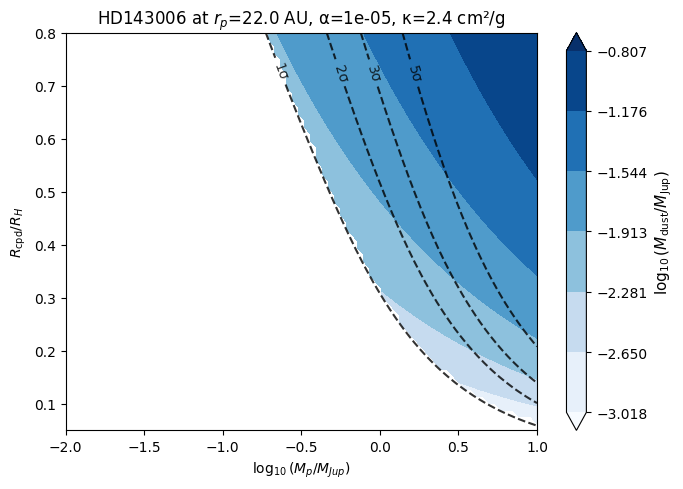

Calculating for Mp = 0.010 Mjup, Rout_frac = 0.050 -> RHill = 0.65 au
 The maximum tau for Rout  = 0 and is nan 
Calculating for Mp = 0.011 Mjup, Rout_frac = 0.050 -> RHill = 0.67 au
 The maximum tau for Rout  = 0 and is 2.289e+01 
Calculating for Mp = 0.012 Mjup, Rout_frac = 0.050 -> RHill = 0.69 au
 The maximum tau for Rout  = 0 and is 2.421e+01 
Calculating for Mp = 0.013 Mjup, Rout_frac = 0.050 -> RHill = 0.71 au
 The maximum tau for Rout  = 0 and is 2.559e+01 
Calculating for Mp = 0.014 Mjup, Rout_frac = 0.050 -> RHill = 0.73 au
 The maximum tau for Rout  = 0 and is 2.703e+01 
Calculating for Mp = 0.015 Mjup, Rout_frac = 0.050 -> RHill = 0.75 au
 The maximum tau for Rout  = 0 and is 2.851e+01 
Calculating for Mp = 0.017 Mjup, Rout_frac = 0.050 -> RHill = 0.77 au
 The maximum tau for Rout  = 0 and is 3.004e+01 
Calculating for Mp = 0.018 Mjup, Rout_frac = 0.050 -> RHill = 0.79 au
 The maximum tau for Rout  = 0 and is 3.163e+01 
Calculating for Mp = 0.020 Mjup, Rout_frac = 0.050 -> 

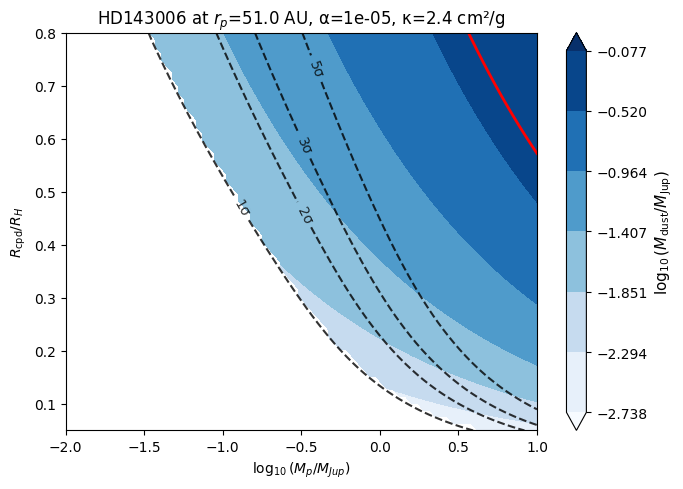

In [7]:
HD1423006_disk_arr = ["HD143006", 1.56, 167, 3.8]

HD1423006_target_flux_arr = [71, 79, 88, 97, 111, 220]  # mu Jy for different recovery fractions from 0.5 to 1.0

rD22 = 22 #140 * HD1423006_disk_arr[2] / 1000  # arcsec to au
rD51 = 51 #315* HD1423006_disk_arr[2] / 1000  # arcsec to au

# Run for the D22 gap
zhu_plots_flux_map(
    target_flux_arr=HD1423006_target_flux_arr,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    lam_mm=1.25,
    alpha=1e-5,
    plotmass=True
)

# Run for the D51 gap
zhu_plots_flux_map(
    target_flux_arr=HD1423006_target_flux_arr,
    disk_arr=HD1423006_disk_arr,
    rp=rD51,
    lam_mm=1.25,
    alpha=1e-5,
    plotmass=True
)

In [ ]:
def Zhu_compute_flux_map(
    target_flux_arr,
    disk_arr,
    rp=165,
    alpha=1e-3,
    y_max=0.8,
    y_min=0.05,
    overwrite=False,
    save=True,
    verbose=True,
    lam_mm=1.25,
    mode="5sigsource",
    n_jobs=4,
):
    """
    Compute Zhu et al. (2018) CPD flux and minimum detectable mass grids.
    Uses parallel processing with joblib for (Rout/RH, Mp) parameter space.

    Parameters
    ----------
    target_flux_arr : list
        Detection threshold(s) [µJy]; typically a list with one value.
    disk_arr : list
        [name, M_star [Msun], d_pc [pc], L_star [Lsun]]
    rp : float
        Planet orbital radius [AU]
    alpha : float
        Viscosity parameter
    y_max, y_min : float
        Range of Rout/RHill fractions
    lam_mm : float
        Wavelength [mm]
    n_jobs : int
        Number of CPU cores for parallelization
    """

    # ================================================================
    # === 1. Setup output directory and cache =========================
    # ================================================================
    save_dir = "Zhu2"
    os.makedirs(save_dir, exist_ok=True)
    fname = f"{disk_arr[0]}_{rp}_alpha{alpha}_{mode}.csv"
    save_path = os.path.join(save_dir, fname)

    if save and os.path.exists(save_path) and not overwrite:
        if verbose:
            print(f"[INFO] Loading cached results from {save_path}")
        df = pd.read_csv(save_path)
        Mp_grid = df["Mp_grid"].unique()
        Rout_frac_grid = df["Rout_frac_grid"].unique()
        Flux_vals = df["Flux_vals"].values.reshape(len(Rout_frac_grid), len(Mp_grid))
        M_cpd_chosen = df["Mcpd_vals"].values.reshape(len(Rout_frac_grid), len(Mp_grid))
        return Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen

    # ================================================================
    # === 2. Define grids ============================================
    # ================================================================
    Mp_grid = np.logspace(-2, 1.25, 100)   # Planet mass grid [Mjup]
    # M_cpd_grid = np.logspace(-5.5, -3, 80) # CPD mass grid [Mjup]
    Rout_frac_grid = np.linspace(y_min, y_max, 80)
    M_star_jup = disk_arr[1] * 1047.56     # Msun → Mjup

    # ================================================================
    # === 3. Define per-cell computation ==============================
    # ================================================================
    def compute_cell(i, j, frac, Mp):
        """Compute one (Rout/RH, Mp) grid cell."""
        try:
            # --- Hill radius & outer disk radius (in AU) ---
            RHill = rp * (Mp / (3 * M_star_jup)) ** (1/3)
            Rout = frac * RHill

            # --- Skip unphysical small disks ---
            Rp_planet = Rp_from_Mp(Mp)  # [Rjup]
            Rp_planet_AU = Rp_planet * R_jup / AU
            if Rout <= Rp_planet_AU:
                return (i, j, 0.0, 0.0)

            # --- Iterate through CPD masses until flux threshold reached ---
            for M_cpd in M_cpd_grid:
                out = calculate_disk_properties_zhu(
                    M_star=disk_arr[1],
                    Mp=Mp,
                    Mdot=Mp*1e-6,   # stellar mass (M jup)/ Myr
                    alpha=alpha,
                    rp=rp,
                    d_pc=disk_arr[2],
                    lam_mm=lam_mm,
                    T_ISM=10.0,
                    Lstar=disk_arr[3],
                    Rout=Rout,
                )
                flux = out["F_nu_tot"]

                # Stop at first mass exceeding detection threshold
                if flux >= target_flux_arr[0]:
                    return (i, j, flux, M_cpd)

                # No detection: return zeros
            return (i, j, 0.0, 0.0)
            
            

        except Exception as e:
            if verbose:
                print(f"[WARN] Cell (i={i}, j={j}) failed: {e}")
            return (i, j, 0.0, 0.0)

    # ================================================================
    # === 4. Run parallel computation ================================
    # ================================================================
    if verbose:
        print(f"[INFO] Running Zhu grid using {n_jobs if n_jobs > 0 else os.cpu_count()} cores...")

    results = Parallel(n_jobs=n_jobs, backend="loky", verbose=10)(
        delayed(compute_cell)(i, j, frac, Mp)
        for i, frac in enumerate(Rout_frac_grid)
        for j, Mp in enumerate(Mp_grid)
    )

    # ================================================================
    # === 5. Collect and reshape results ==============================
    # ================================================================
    Flux_vals = np.zeros((len(Rout_frac_grid), len(Mp_grid)))
    M_cpd_chosen = np.zeros_like(Flux_vals)

    for i, j, flux, M_cpd in results:
        Flux_vals[i, j] = flux
        M_cpd_chosen[i, j] = M_cpd

    # ================================================================
    # === 6. Summary and diagnostics =================================
    # ================================================================
    if verbose:
        n_nonzero = np.sum(Flux_vals > 0)
        print(f"[INFO] Non-zero flux points: {n_nonzero}/{Flux_vals.size}")
        if n_nonzero == 0:
            print("[WARN] All fluxes are zero — check units or disk model scaling.")

    # ================================================================
    # === 7. Save to CSV (optional) ==================================
    # ================================================================
    if save:
        df = pd.DataFrame({
            "Mp_grid": np.tile(Mp_grid, len(Rout_frac_grid)),
            "Rout_frac_grid": np.repeat(Rout_frac_grid, len(Mp_grid)),
            "Flux_vals": Flux_vals.flatten(),
            "Mcpd_vals": M_cpd_chosen.flatten(),
        })
        df.to_csv(save_path, index=False)
        if verbose:
            print(f"[INFO] Saved results to {save_path}")

    # ================================================================
    # === 8. Return final data =======================================
    # ================================================================
    return Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen

Define the plotting function

In [ ]:
# Now I want to 
import numpy as np
from scipy.optimize import curve_fit


def broken_power_law(x, x_break, a1, a2, b1, b2):
    """Piecewise power law: y = a1*x^b1 for x < x_break, y = a2*x^b2 for x >= x_break"""
    return np.where(x < x_break, a1 * x**b1, a2 * x**b2)

# Initial guess: x_break, a1, a2, b1, b2 
p0 = [np.median(x), 1, 1, -1, -2]

popt, pcov = curve_fit(broken_power_law, x, y, p0=p0)

print("Best-fit parameters:", popt)

In [ ]:
# add in discussion why it is not a minimum mass S


#------------------------------------------------------------
#-----Equate Tb at tau = 0.5 to solve for minimum sigma------
#------------------------------------------------------------

val = (3/8) * (kappaR / kappa_mm) * Teff**4 + T_ext**4
Sigma_tau05 = (val**4 - T_ext**4)*(1-(Rin/R)**(0.5))**(-1)*(128*np.pi*R**3*sigmaB)/(9*G*Mp*Mdot*kappa_R)